# 04 - Deep Learning CNN: SimpleCNN vs DeepCNN Benchmark

This notebook trains and compares both CNN architectures (`SimpleCNN` and `DeepCNN`) on augmented MRI tensor files (`.pt`), utilizing a **ReduceLROnPlateau learning rate scheduler** and **Early Stopping** based on validation accuracy. All core logic is imported from `src/`.

In [1]:
import os
import sys
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split
from dotenv import load_dotenv
import torch 
# Add src directory to path
sys.path.append(os.path.abspath(os.path.join('..')))
from src.models import SimpleCNN, DeepCNN, AttentionCNN
from src.training import train_advanced_cnn_with_early_stopping
from src.evaluation import evaluate_cnn_model
%matplotlib inline
load_dotenv()

True

## 1. Load Augmented Tensors & Split into Train / Validation / Test

In [2]:
PROCESSED_DIR = os.getenv("PROCESSED_DIR", os.path.join("data", "processed"))
AUG_DIR = os.path.join(PROCESSED_DIR, "augmented_images")

if not os.path.exists(AUG_DIR):
    AUG_DIR = os.path.join("..", "data", "processed", "augmented_images")

yes_aug_dir = os.path.join(AUG_DIR, "yes")
no_aug_dir = os.path.join(AUG_DIR, "no")

images = []
labels = []

if os.path.exists(no_aug_dir):
    for file in os.listdir(no_aug_dir):
        if file.endswith('.pt'):
            images.append(torch.load(os.path.join(no_aug_dir, file)))
            labels.append(0)

if os.path.exists(yes_aug_dir):
    for file in os.listdir(yes_aug_dir):
        if file.endswith('.pt'):
            images.append(torch.load(os.path.join(yes_aug_dir, file)))
            labels.append(1)

print(f"Total loaded tensors (.pt): {len(images)}")

# Split: 70% Train, 15% Validation (for Early Stopping), 15% Test
X_temp, X_test, y_temp, y_test = train_test_split(images, labels, test_size=0.15, random_state=42, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1764, random_state=42, stratify=y_temp)

print(f"Train set: {len(X_train)} | Validation set: {len(X_val)} | Test set: {len(X_test)}")

Total loaded tensors (.pt): 504
Train set: 352 | Validation set: 76 | Test set: 76


## 2. Training SimpleCNN with Early Stopping & LR Scheduler

In [3]:
print("=== Training SimpleCNN ===")
simple_cnn = SimpleCNN(input_channels=3, num_classes=2)

trained_simple, history_simple, best_acc_simple = train_advanced_cnn_with_early_stopping(
    model=simple_cnn,
    train_images=X_train, train_labels=y_train,
    val_images=X_val, val_labels=y_val,
    optimizer_type='AdamW',
    lr=0.001,
    epochs=200,
    batch_size=32,
    patience=20
)

print(f"\nSimpleCNN Best Validation Accuracy: {best_acc_simple:.2f}%")

=== Training SimpleCNN ===
Epoch [1/200] | Train Loss: 0.6564 | Val Accuracy: 63.16%
   ✨ Meilleure accuracy validation : 63.16% (Poids sauvegardés)
Epoch [2/200] | Train Loss: 0.6011 | Val Accuracy: 80.26%
   ✨ Meilleure accuracy validation : 80.26% (Poids sauvegardés)
Epoch [3/200] | Train Loss: 0.5531 | Val Accuracy: 78.95%
   ⏳ Stagnation (1/20)
Epoch [4/200] | Train Loss: 0.5288 | Val Accuracy: 77.63%
   ⏳ Stagnation (2/20)
Epoch [5/200] | Train Loss: 0.5105 | Val Accuracy: 78.95%
   ⏳ Stagnation (3/20)
Epoch [6/200] | Train Loss: 0.5089 | Val Accuracy: 78.95%
   ⏳ Stagnation (4/20)
Epoch [7/200] | Train Loss: 0.4973 | Val Accuracy: 78.95%
   ⏳ Stagnation (5/20)
Epoch [8/200] | Train Loss: 0.4976 | Val Accuracy: 77.63%
   ⏳ Stagnation (6/20)
Epoch [9/200] | Train Loss: 0.4928 | Val Accuracy: 78.95%
   ⏳ Stagnation (7/20)
Epoch [10/200] | Train Loss: 0.4849 | Val Accuracy: 77.63%
   ⏳ Stagnation (8/20)
Epoch [11/200] | Train Loss: 0.4833 | Val Accuracy: 78.95%
   ⏳ Stagnation (9/20

## 3. Training DeepCNN with Early Stopping & LR Scheduler

In [4]:
print("=== Training DeepCNN ===")
deep_cnn = DeepCNN(input_channels=3, num_classes=2)

trained_deep, history_deep, best_acc_deep = train_advanced_cnn_with_early_stopping(
    model=deep_cnn,
    train_images=X_train, train_labels=y_train,
    val_images=X_val, val_labels=y_val,
    optimizer_type='AdamW',
    lr=0.001,
    epochs=200,
    batch_size=32,
    patience=20
)

print(f"\nDeepCNN Best Validation Accuracy: {best_acc_deep:.2f}%")

=== Training DeepCNN ===
Epoch [1/200] | Train Loss: 1.2558 | Val Accuracy: 38.16%
   ✨ Meilleure accuracy validation : 38.16% (Poids sauvegardés)
Epoch [2/200] | Train Loss: 0.8587 | Val Accuracy: 46.05%
   ✨ Meilleure accuracy validation : 46.05% (Poids sauvegardés)
Epoch [3/200] | Train Loss: 0.6178 | Val Accuracy: 69.74%
   ✨ Meilleure accuracy validation : 69.74% (Poids sauvegardés)
Epoch [4/200] | Train Loss: 0.6042 | Val Accuracy: 51.32%
   ⏳ Stagnation (1/20)
Epoch [5/200] | Train Loss: 0.5331 | Val Accuracy: 78.95%
   ✨ Meilleure accuracy validation : 78.95% (Poids sauvegardés)
Epoch [6/200] | Train Loss: 0.4494 | Val Accuracy: 77.63%
   ⏳ Stagnation (1/20)
Epoch [7/200] | Train Loss: 0.4069 | Val Accuracy: 80.26%
   ✨ Meilleure accuracy validation : 80.26% (Poids sauvegardés)
Epoch [8/200] | Train Loss: 0.3864 | Val Accuracy: 88.16%
   ✨ Meilleure accuracy validation : 88.16% (Poids sauvegardés)
Epoch [9/200] | Train Loss: 0.3130 | Val Accuracy: 89.47%
   ✨ Meilleure accuracy

## 4. Training DeepAttentionCNN with Early Stopping & LR Scheduler

In [9]:
print("=== Training DeepAttentionCNN ===")
deep_attention_cnn = AttentionCNN(input_channels=3, num_classes=2)

trained_deep_attention, history_deep_attention, best_acc_deep_attention = train_advanced_cnn_with_early_stopping(
    model=deep_attention_cnn,
    train_images=X_train, train_labels=y_train,
    val_images=X_val, val_labels=y_val,
    optimizer_type='AdamW',
    lr=0.001,
    epochs=200,
    batch_size=32,
    patience=20
)

print(f"\nDeepAdaptativeCNN Best Validation Accuracy: {best_acc_deep_attention:.2f}%")

=== Training DeepAdaptativeCNN ===
Epoch [1/200] | Train Loss: 0.6284 | Val Accuracy: 69.74%
   ✨ Meilleure accuracy validation : 69.74% (Poids sauvegardés)
Epoch [2/200] | Train Loss: 0.5355 | Val Accuracy: 71.05%
   ✨ Meilleure accuracy validation : 71.05% (Poids sauvegardés)
Epoch [3/200] | Train Loss: 0.4347 | Val Accuracy: 72.37%
   ✨ Meilleure accuracy validation : 72.37% (Poids sauvegardés)
Epoch [4/200] | Train Loss: 0.3116 | Val Accuracy: 88.16%
   ✨ Meilleure accuracy validation : 88.16% (Poids sauvegardés)
Epoch [5/200] | Train Loss: 0.1958 | Val Accuracy: 77.63%
   ⏳ Stagnation (1/20)
Epoch [6/200] | Train Loss: 0.1997 | Val Accuracy: 89.47%
   ✨ Meilleure accuracy validation : 89.47% (Poids sauvegardés)
Epoch [7/200] | Train Loss: 0.1140 | Val Accuracy: 71.05%
   ⏳ Stagnation (1/20)
Epoch [8/200] | Train Loss: 0.0651 | Val Accuracy: 88.16%
   ⏳ Stagnation (2/20)
Epoch [9/200] | Train Loss: 0.0538 | Val Accuracy: 82.89%
   ⏳ Stagnation (3/20)
Epoch [10/200] | Train Loss: 0.

## 4. Model Comparison (SimpleCNN vs DeepCNN)
We plot and compare the validation accuracy and training loss trajectories of both CNN models.

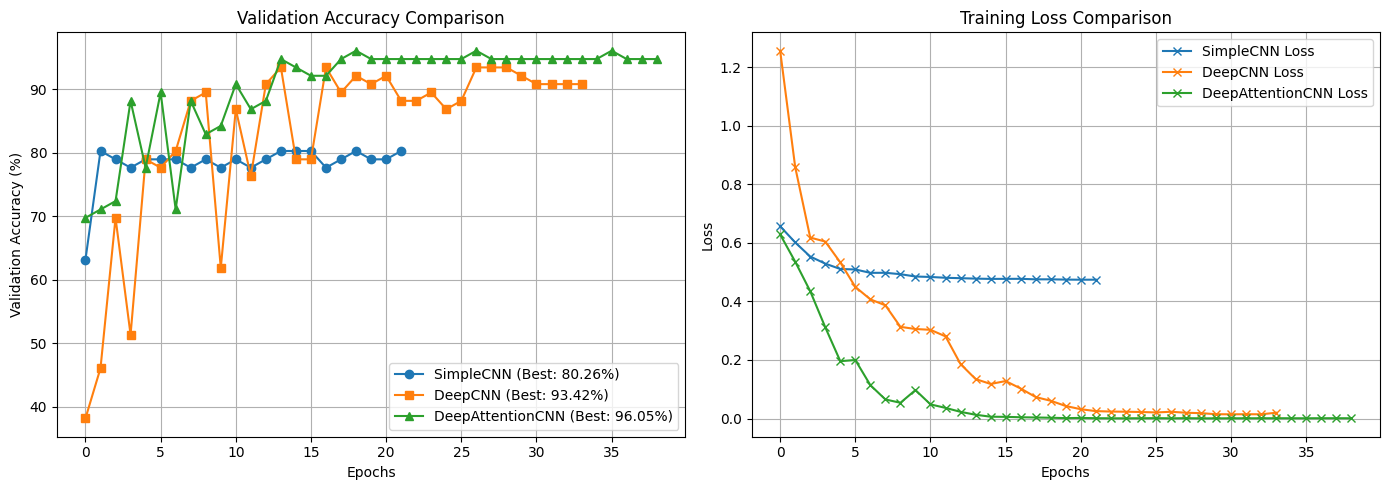

=== COMPARISON SUMMARY ===
SimpleCNN Validation Accuracy : 80.26%
DeepCNN Validation Accuracy   : 93.42%
DeepAttentionCNN Validation Accuracy : 96.05%


In [11]:
plt.figure(figsize=(14, 5))

# Validation Accuracy Comparison
plt.subplot(1, 2, 1)
plt.plot(history_simple['val_accuracy'], marker='o', label=f'SimpleCNN (Best: {max(history_simple["val_accuracy"]):.2f}%)')
plt.plot(history_deep['val_accuracy'], marker='s', label=f'DeepCNN (Best: {max(history_deep["val_accuracy"]):.2f}%)')
plt.plot(history_deep_attention['val_accuracy'], marker='^', label=f'DeepAttentionCNN (Best: {max(history_deep_attention["val_accuracy"]):.2f}%)')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.grid(True)

# Training Loss Comparison
plt.subplot(1, 2, 2)
plt.plot(history_simple['train_loss'], marker='x', label='SimpleCNN Loss')
plt.plot(history_deep['train_loss'], marker='x', label='DeepCNN Loss')
plt.plot(history_deep_attention['train_loss'], marker='x', label='DeepAttentionCNN Loss')
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("=== COMPARISON SUMMARY ===")
print(f"SimpleCNN Validation Accuracy : {best_acc_simple:.2f}%")
print(f"DeepCNN Validation Accuracy   : {best_acc_deep:.2f}%")
print(f"DeepAttentionCNN Validation Accuracy : {best_acc_deep_attention:.2f}%")

## Comparaison des Métriques (Accuracy, Precision, Recall, F1-Score)
Évaluation et affichage du tableau comparatif des performances entre le SimpleCNN et le DeepCNN sur le jeu de test.

In [12]:
# Évaluation des deux modèles sur le jeu de test
metrics_simple, _, _ = evaluate_cnn_model(trained_simple, X_test, y_test)
metrics_deep, _, _ = evaluate_cnn_model(trained_deep, X_test, y_test)
metrics_deep_attention, _, _ = evaluate_cnn_model(trained_deep_attention, X_test, y_test)
# Construction du tableau comparatif des métriques
cnn_performance_df = pd.DataFrame([
    {
        "Model": "SimpleCNN",
        "Accuracy": metrics_simple["Accuracy"],
        "Precision": metrics_simple["Precision"],
        "Recall": metrics_simple["Recall"],
        "F1-Score": metrics_simple["F1-Score"]
    },
    {
        "Model": "DeepCNN",
        "Accuracy": metrics_deep["Accuracy"],
        "Precision": metrics_deep["Precision"],
        "Recall": metrics_deep["Recall"],
        "F1-Score": metrics_deep["F1-Score"]
    },
    {
        "Model": "DeepAttentionCNN",
        "Accuracy": metrics_deep_attention["Accuracy"],
        "Precision": metrics_deep_attention["Precision"],
        "Recall": metrics_deep_attention["Recall"],
        "F1-Score": metrics_deep_attention["F1-Score"]
    }
]).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("=== TABLEAU COMPARATIF DES MÉTRIQUES (SimpleCNN vs DeepCNN vs DeepAttentionCNN) ===")
display(cnn_performance_df.style.background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], cmap='Blues'))

=== TABLEAU COMPARATIF DES MÉTRIQUES (SimpleCNN vs DeepCNN vs DeepAttentionCNN) ===


,Model,Accuracy,Precision,Recall,F1-Score
0,DeepAttentionCNN,0.934211,0.976744,0.913043,0.943820
1,DeepCNN,0.894737,0.865385,0.978261,0.918367
2,SimpleCNN,0.763158,0.733333,0.956522,0.830189


In [16]:
import os
import torch

# Définition du dossier de sauvegarde
save_dir = os.path.join("..", "models")
if not os.path.exists(save_dir):
    save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

# Dictionnaire associant le nom du fichier aux variables potentielles de vos notebooks
models_to_save = {
    "SimpleCNN_Trained.pth": locals().get("trained_simple", None),
    "DeepCNN_Trained.pth": locals().get("trained_deep", None),
    "Attention_CNN_Trained.pth": locals().get("trained_deep_attention", None)
}

saved_count = 0
print("💾 Sauvegarde des modèles entraînés en cours...")

for filename, model_instance in models_to_save.items():
    if model_instance is not None:
        file_path = os.path.join(save_dir, filename)
        # Sauvegarde des poids (recommandé par rapport au modèle complet)
        torch.save(model_instance.state_dict(), file_path)
        print(f"   ✅ Sauvegardé : {file_path}")
        saved_count += 1

print(f"\n✨ Opération terminée ! {saved_count} modèle(s) sauvegardé(s) dans '{save_dir}'.")

💾 Sauvegarde des modèles entraînés en cours...
   ✅ Sauvegardé : ..\models\SimpleCNN_Trained.pth
   ✅ Sauvegardé : ..\models\DeepCNN_Trained.pth
   ✅ Sauvegardé : ..\models\Attention_CNN_Trained.pth

✨ Opération terminée ! 3 modèle(s) sauvegardé(s) dans '..\models'.
